# Predicting Smartphone Addiction

**Module:** CIS6005 Computational Intelligence  
**Assessment:** WRIT1  
**Competition:** Predicting Smartphone Addiction — Playground Series, Season 6 Episode 8  
**Student ID:** 20302367

## Notebook objectives

This notebook implements the complete machine-learning workflow:

1. Configure Google Colab and Google Drive.
2. Load and inspect the Kaggle competition data.
3. Perform exploratory data analysis.
4. Build leakage-safe preprocessing pipelines.
5. Train and compare multiple computational-intelligence models.
6. Evaluate models using validation and cross-validation.
7. Train and save the selected final model.
8. Generate and validate a Kaggle submission.

> **Important:** Confirm the official Kaggle evaluation metric from the competition's **Overview → Evaluation** page. This notebook uses ROC AUC because the supplied sample submission contains probability-like values for the binary target. Change `OFFICIAL_METRIC` if Kaggle specifies another metric.

## 1. Google Colab and project setup

Mount Google Drive so that the notebook, generated figures, trained models, experiment results and submissions remain available after the Colab runtime disconnects.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/smartphone-addiction-project"
)

DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
SUBMISSION_DIR = OUTPUT_DIR / "submissions"
RESULTS_DIR = OUTPUT_DIR / "results"

for directory in [
    DATA_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    SUBMISSION_DIR,
    RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")

Project directory: /content/drive/MyDrive/smartphone-addiction-project


## 2. Install and import dependencies

The notebook pins no package versions during experimentation, but it records the final environment later. Use the recorded versions in the API's `requirements.txt` to avoid model-loading compatibility issues.

In [3]:
!pip install -q pandas numpy matplotlib scikit-learn lightgbm xgboost joblib

In [4]:
import json
import platform
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.13
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1


## 3. Load the Kaggle data

Place the following competition files in the Google Drive `data` folder:

- `train.csv`
- `test.csv`
- `sample_submission.csv`

In [5]:
required_files = [
    DATA_DIR / "train.csv",
    DATA_DIR / "test.csv",
    DATA_DIR / "sample_submission.csv",
]

missing_files = [
    str(path)
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(missing_files)
    )

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(
    DATA_DIR / "sample_submission.csv"
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

display(train_df.head())
display(test_df.head())
display(sample_submission.head())

Train shape: (691369, 14)
Test shape: (296302, 13)
Sample submission shape: (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


,id,addicted_label
0,691369,0.709424
1,691370,0.709424
2,691371,0.709424
3,691372,0.709424
4,691373,0.709424


## 4. Dataset inspection

In [6]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nSample submission columns:")
print(sample_submission.columns.tolist())

target_candidates = [
    column
    for column in train_df.columns
    if column not in test_df.columns
]

if len(target_candidates) != 1:
    raise ValueError(
        "Expected exactly one target candidate, but found: "
        f"{target_candidates}"
    )

TARGET = target_candidates[0]

id_candidates = [
    column
    for column in test_df.columns
    if column.lower() in {
        "id",
        "user_id",
        "participant_id",
        "student_id",
    }
]

ID_COLUMN = id_candidates[0] if id_candidates else None

print("\nDetected target:", TARGET)
print("Detected ID column:", ID_COLUMN)
print("Target dtype:", train_df[TARGET].dtype)
print("Target unique values:", sorted(train_df[TARGET].dropna().unique().tolist()))

Train columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact', 'addicted_label']

Test columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender', 'stress_level', 'academic_work_impact']

Sample submission columns:
['id', 'addicted_label']

Detected target: addicted_label
Detected ID column: id
Target dtype: int64
Target unique values: [0, 1]


In [7]:
print("Training data information:")
train_df.info()

dataset_summary = {
    "train_rows": int(train_df.shape[0]),
    "train_columns": int(train_df.shape[1]),
    "test_rows": int(test_df.shape[0]),
    "test_columns": int(test_df.shape[1]),
    "target": TARGET,
    "id_column": ID_COLUMN,
    "duplicate_rows": int(train_df.duplicated().sum()),
}

with open(
    RESULTS_DIR / "dataset_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(dataset_summary, file, indent=2)

print("\nDuplicate training rows:", dataset_summary["duplicate_rows"])

Training data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 

## 5. Exploratory Data Analysis

The EDA should not only describe the data. It should also explain how the findings influence preprocessing, validation and model selection.

In [8]:
missing_report = pd.DataFrame({
    "data_type": train_df.dtypes.astype(str),
    "missing_count": train_df.isna().sum(),
    "missing_percentage": train_df.isna().mean() * 100,
    "unique_values": train_df.nunique(dropna=False),
}).sort_values(
    "missing_percentage",
    ascending=False,
)

missing_report.to_csv(
    RESULTS_DIR / "column_summary.csv"
)

display(missing_report)

,data_type,missing_count,missing_percentage,unique_values
social_media_hours,float64,133995,19.381112,722
gaming_hours,float64,126821,18.343461,402
weekend_screen_time,float64,112063,16.208855,1438
daily_screen_time_hours,float64,95854,13.864376,1390
app_opens_per_day,float64,80710,11.673940,167
notifications_per_day,float64,67584,9.775388,232
stress_level,object,55148,7.976638,4
work_study_hours,float64,51518,7.451592,601
sleep_hours,float64,44480,6.433612,452
academic_work_impact,object,44224,6.396584,3


,count,percentage
addicted_label,,
1,490474,70.942435
0,200895,29.057565


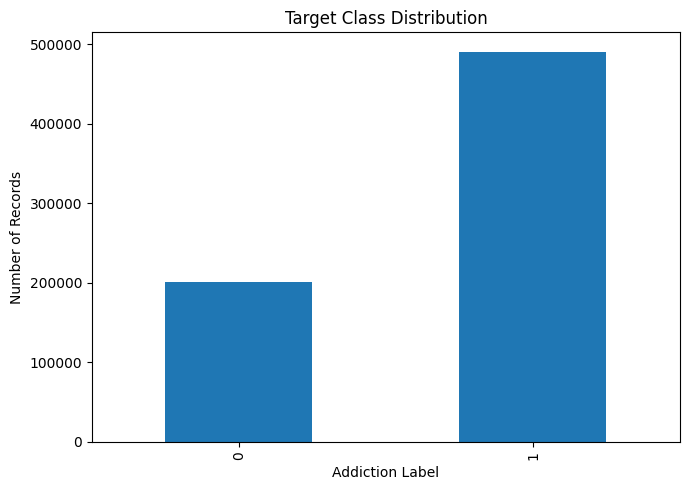

In [9]:
target_counts = train_df[TARGET].value_counts(dropna=False)
target_percentages = (
    train_df[TARGET]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages,
})

display(target_summary)

ax = target_counts.sort_index().plot(
    kind="bar",
    figsize=(7, 5),
)
ax.set_title("Target Class Distribution")
ax.set_xlabel("Addiction Label")
ax.set_ylabel("Number of Records")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [10]:
excluded_columns = [TARGET]

if ID_COLUMN is not None:
    excluded_columns.append(ID_COLUMN)

feature_columns = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

X = train_df[feature_columns].copy()
y = train_df[TARGET].copy()
X_test = test_df[feature_columns].copy()

numeric_columns = (
    X.select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_columns = (
    X.select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

print("Feature count:", len(feature_columns))
print("Numerical features:", numeric_columns)
print("Categorical features:", categorical_columns)

Feature count: 12
Numerical features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
Categorical features: ['gender', 'stress_level', 'academic_work_impact']


,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


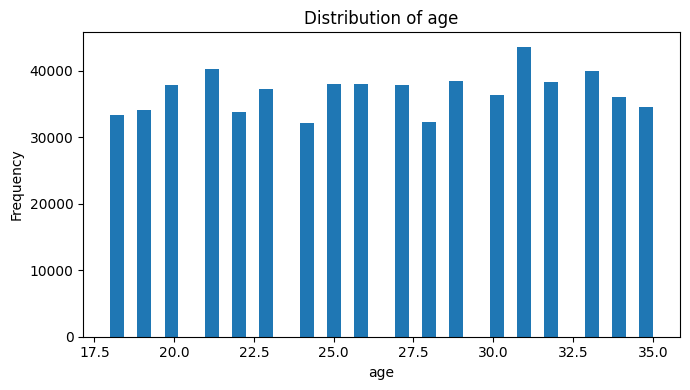

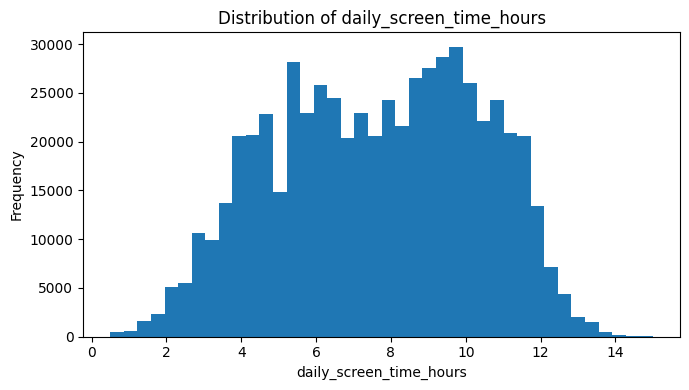

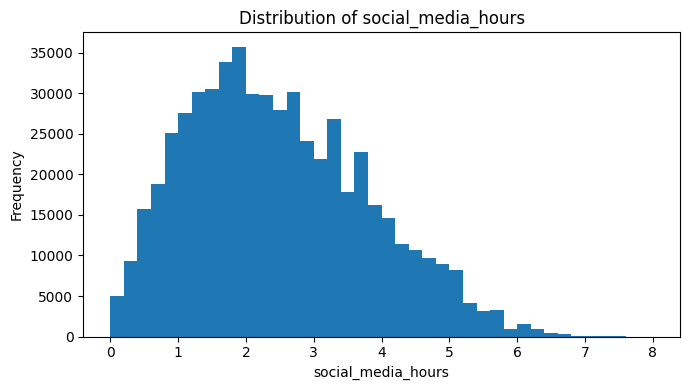

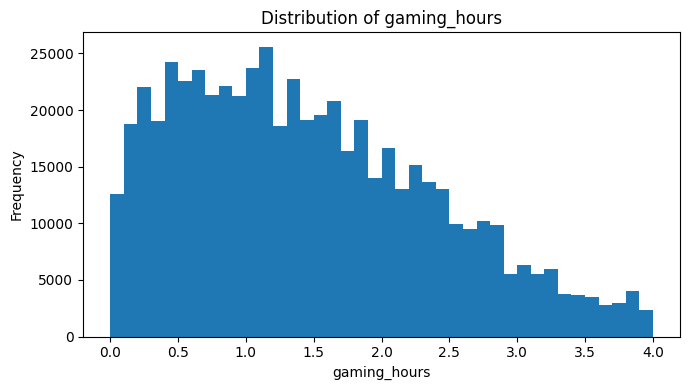

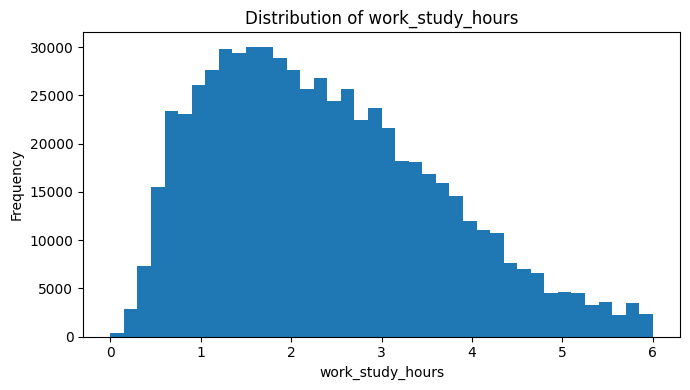

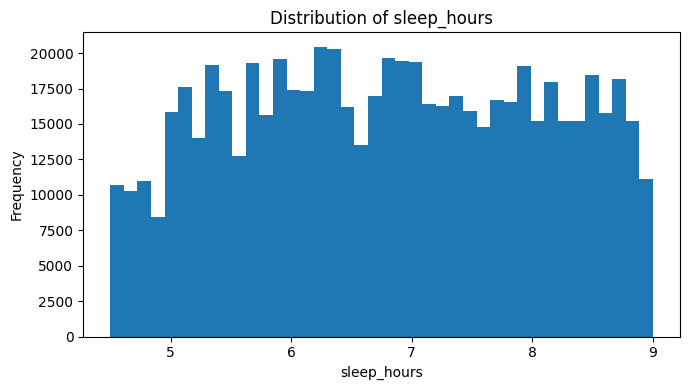

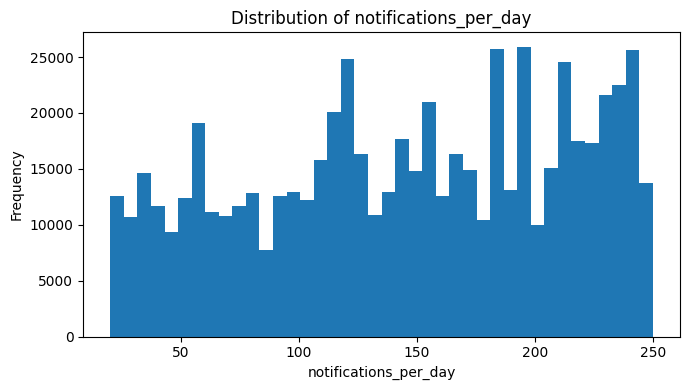

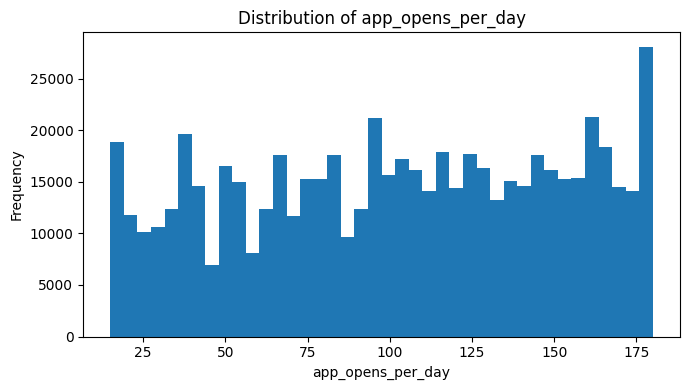

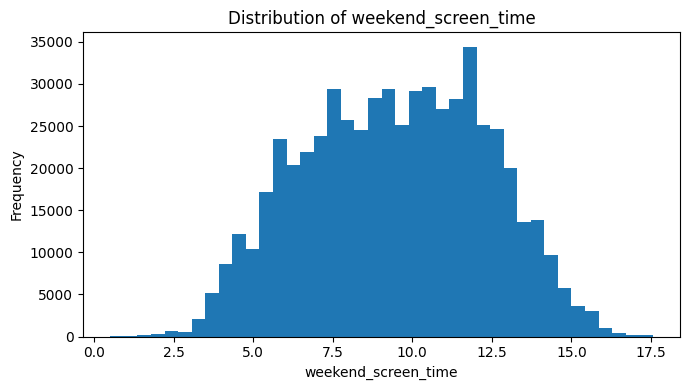

In [11]:
if numeric_columns:
    numeric_summary = X[numeric_columns].describe().T
    display(numeric_summary)
    numeric_summary.to_csv(
        RESULTS_DIR / "numeric_summary.csv"
    )

    for column in numeric_columns:
        plt.figure(figsize=(7, 4))
        X[column].plot(kind="hist", bins=40)
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(
            FIGURE_DIR / f"distribution_{column}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.show()

In [12]:
if categorical_columns:
    categorical_summary_rows = []

    for column in categorical_columns:
        counts = (
            X[column]
            .value_counts(dropna=False)
            .head(20)
        )

        print(f"\nTop values for {column}:")
        display(counts.to_frame("count"))

        for value, count in counts.items():
            categorical_summary_rows.append({
                "feature": column,
                "value": str(value),
                "count": int(count),
            })

    pd.DataFrame(categorical_summary_rows).to_csv(
        RESULTS_DIR / "categorical_summary.csv",
        index=False,
    )


Top values for gender:


,count
gender,
Male,223662
Female,221595
Other,217078
NaN,29034



Top values for stress_level:


,count
stress_level,
High,220873
Low,207783
Medium,207565
NaN,55148



Top values for academic_work_impact:


,count
academic_work_impact,
Yes,330566
No,316579
NaN,44224


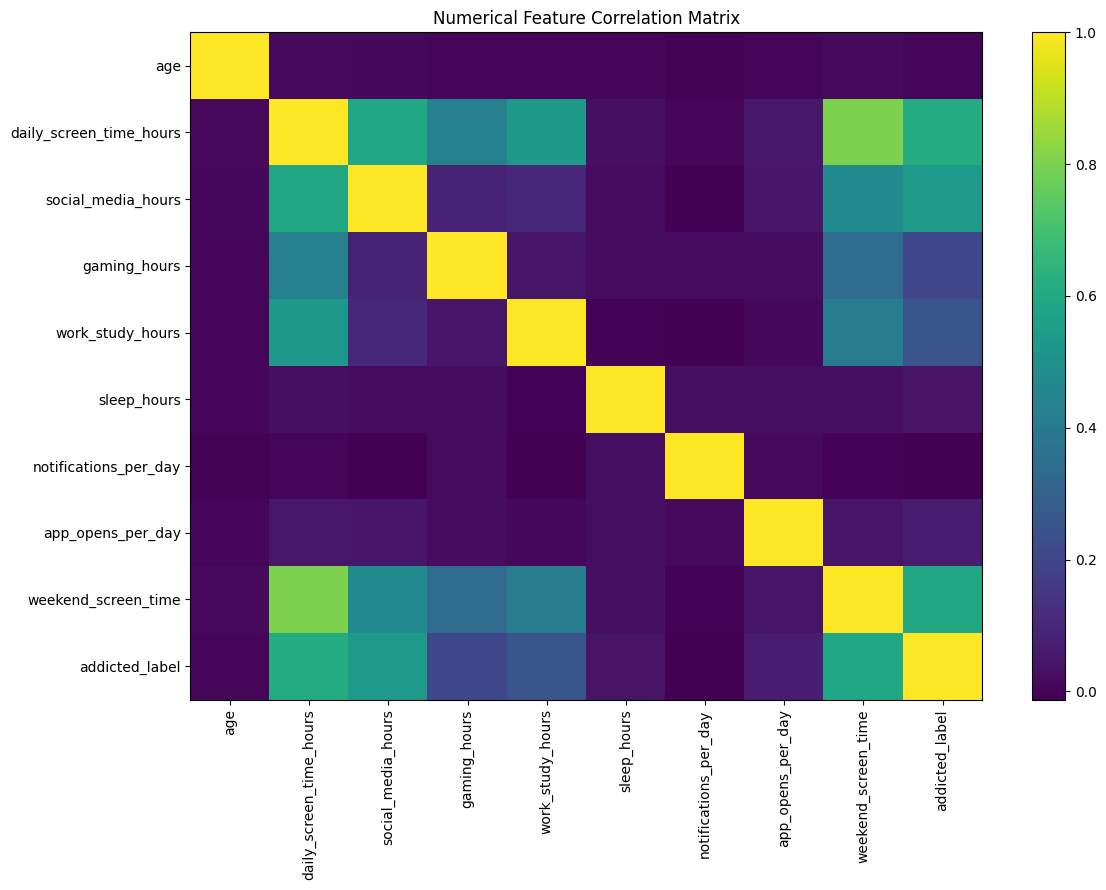

,correlation_with_target
daily_screen_time_hours,0.611398
weekend_screen_time,0.589903
social_media_hours,0.532409
work_study_hours,0.251416
gaming_hours,0.205283
app_opens_per_day,0.063482
sleep_hours,0.042545
notifications_per_day,-0.011583
age,0.004043


In [13]:
if numeric_columns:
    correlation_data = train_df[
        numeric_columns + [TARGET]
    ].corr(numeric_only=True)

    plt.figure(figsize=(12, 9))
    plt.imshow(correlation_data, aspect="auto")
    plt.colorbar()
    plt.xticks(
        range(len(correlation_data.columns)),
        correlation_data.columns,
        rotation=90,
    )
    plt.yticks(
        range(len(correlation_data.columns)),
        correlation_data.columns,
    )
    plt.title("Numerical Feature Correlation Matrix")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "correlation_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    target_correlations = (
        correlation_data[TARGET]
        .drop(TARGET)
        .sort_values(key=abs, ascending=False)
    )

    display(
        target_correlations.to_frame(
            "correlation_with_target"
        )
    )

<Figure size 700x400 with 0 Axes>

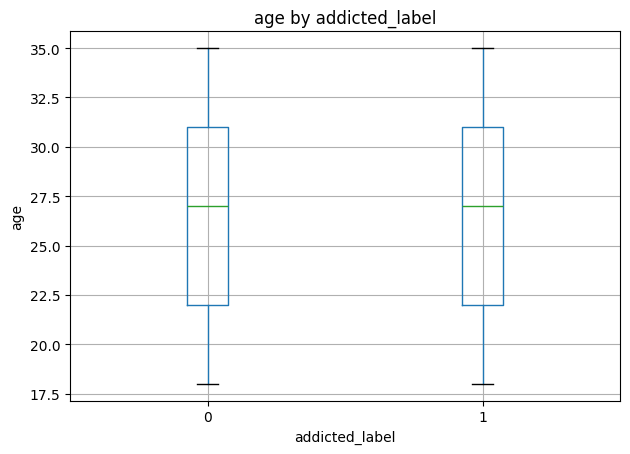

<Figure size 700x400 with 0 Axes>

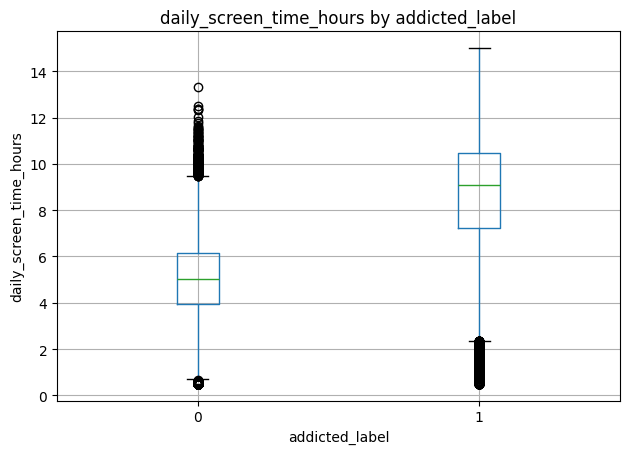

<Figure size 700x400 with 0 Axes>

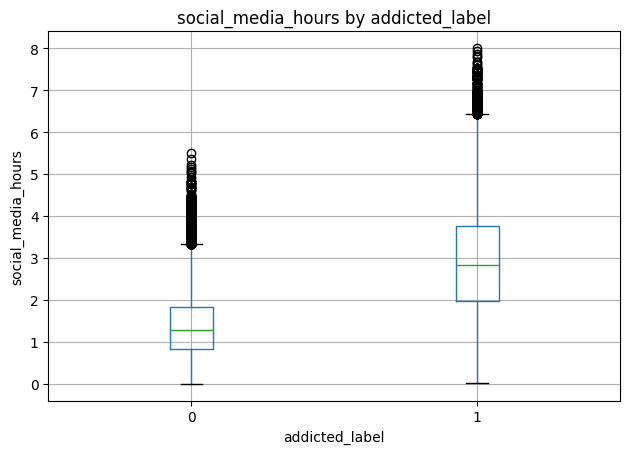

<Figure size 700x400 with 0 Axes>

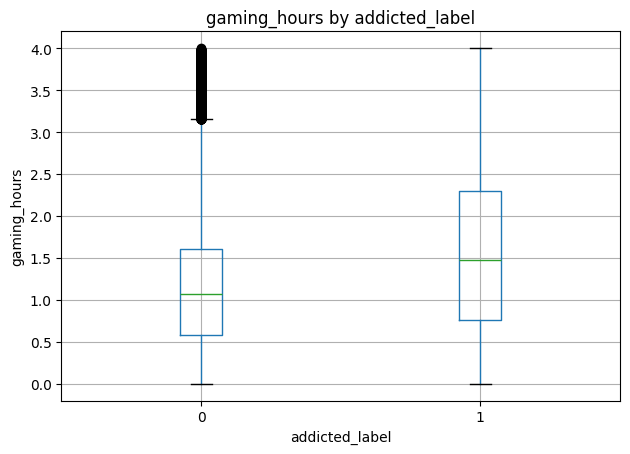

<Figure size 700x400 with 0 Axes>

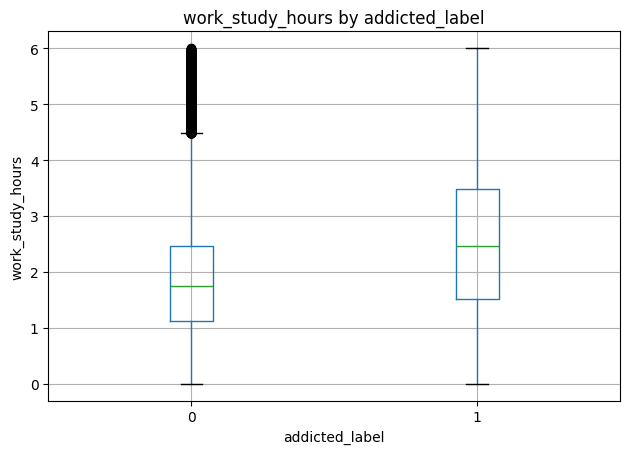

<Figure size 700x400 with 0 Axes>

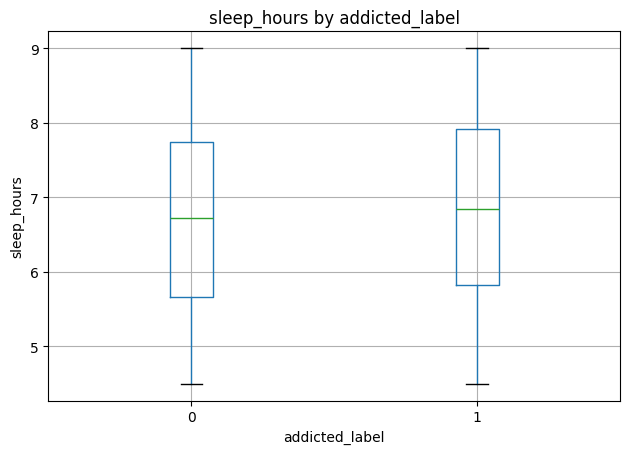

<Figure size 700x400 with 0 Axes>

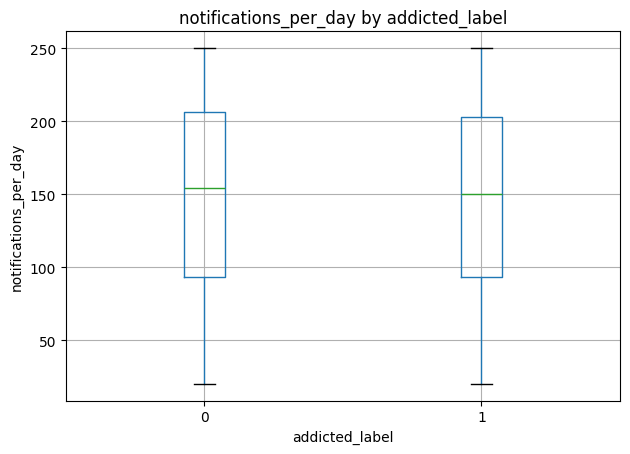

<Figure size 700x400 with 0 Axes>

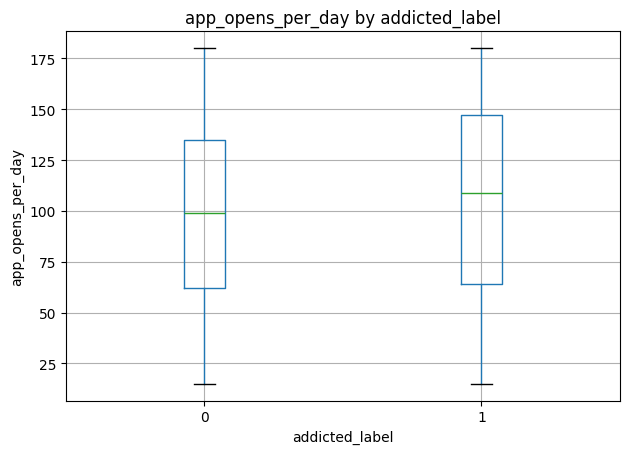

<Figure size 700x400 with 0 Axes>

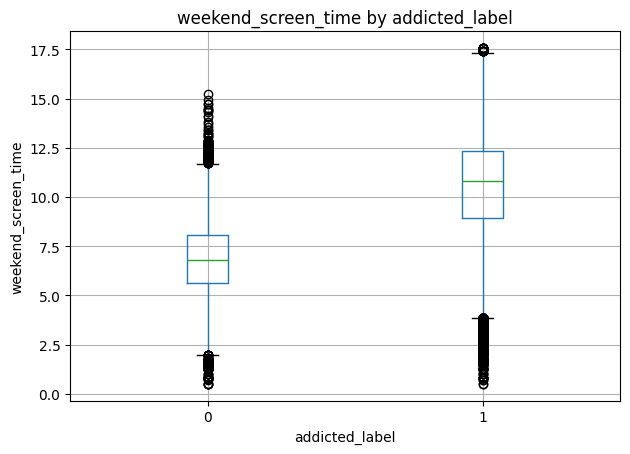


Target rate by gender:


,count,mean
gender,,
Male,223662,0.723198
NaN,29034,0.708790
Female,221595,0.703838
Other,217078,0.701020



Target rate by stress_level:


,count,mean
stress_level,,
High,220873,0.711431
Low,207783,0.711160
NaN,55148,0.709001
Medium,207565,0.705663



Target rate by academic_work_impact:


,count,mean
academic_work_impact,,
No,316579,0.711029
NaN,44224,0.709456
Yes,330566,0.707883


In [14]:
# Compare numerical features with the target.
for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    train_df.boxplot(
        column=column,
        by=TARGET,
    )
    plt.title(f"{column} by {TARGET}")
    plt.suptitle("")
    plt.xlabel(TARGET)
    plt.ylabel(column)
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{column}_by_target.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

# Compare categorical features with the target.
category_target_tables = {}

for column in categorical_columns:
    table = (
        train_df.groupby(column, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    category_target_tables[column] = table

    print(f"\nTarget rate by {column}:")
    display(table.head(30))

In [15]:
# Train-versus-test distribution comparison for numerical columns.
distribution_comparison = []

for column in numeric_columns:
    train_mean = train_df[column].mean()
    test_mean = test_df[column].mean()
    train_std = train_df[column].std()
    test_std = test_df[column].std()

    pooled_std = max(
        np.nanmean([train_std, test_std]),
        1e-9,
    )

    standardized_mean_difference = (
        test_mean - train_mean
    ) / pooled_std

    distribution_comparison.append({
        "feature": column,
        "train_mean": train_mean,
        "test_mean": test_mean,
        "train_std": train_std,
        "test_std": test_std,
        "standardized_mean_difference":
            standardized_mean_difference,
    })

distribution_comparison_df = pd.DataFrame(
    distribution_comparison
).sort_values(
    "standardized_mean_difference",
    key=abs,
    ascending=False,
)

display(distribution_comparison_df)

distribution_comparison_df.to_csv(
    RESULTS_DIR / "train_test_numeric_comparison.csv",
    index=False,
)

,feature,train_mean,test_mean,train_std,test_std,standardized_mean_difference
6,notifications_per_day,145.894900,145.748066,65.917556,66.014554,-0.002226
5,sleep_hours,6.804334,6.801704,1.234512,1.236080,-0.002129
8,weekend_screen_time,9.479866,9.474575,2.856006,2.858384,-0.001852
3,gaming_hours,1.459265,1.457668,0.934552,0.934727,-0.001708
0,age,26.615408,26.608689,5.153162,5.153359,-0.001304
4,work_study_hours,2.366971,2.365962,1.258797,1.257023,-0.000802
7,app_opens_per_day,102.636781,102.656216,48.093970,48.186200,0.000404
2,social_media_hours,2.471038,2.471224,1.316137,1.318143,0.000141
1,daily_screen_time_hours,7.640865,7.640771,2.721446,2.725921,-0.000035


### EDA interpretation template

Complete this table after running the notebook. Replace the placeholder observations with findings supported by the generated results.

| EDA finding | Model-design decision |
|---|---|
| The target classes are imbalanced | Use stratified validation and report metrics beyond accuracy |
| Numerical features use different scales | Standardize them for Logistic Regression and MLP |
| Missing numerical values exist | Use median imputation inside the pipeline |
| Missing categorical values exist | Use most-frequent imputation |
| Categorical features exist | Use one-hot encoding for linear models and native/encoded handling for boosting |
| Non-linear feature-target relationships are visible | Compare tree ensembles and boosting with the linear baseline |

## 6. Optional domain-informed feature engineering

This function creates only features whose required source columns actually exist. Review the generated columns and explain every retained feature in the report.

In [16]:
def add_domain_features(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    result = dataframe.copy()

    # Common naming variants are checked safely.
    candidate_pairs = [
        (
            "social_media_ratio",
            "social_media_hours",
            "daily_screen_time_hours",
        ),
        (
            "gaming_ratio",
            "gaming_hours",
            "daily_screen_time_hours",
        ),
        (
            "notifications_per_screen_hour",
            "notifications_per_day",
            "daily_screen_time_hours",
        ),
        (
            "unlocks_per_screen_hour",
            "phone_unlocks_per_day",
            "daily_screen_time_hours",
        ),
    ]

    for new_column, numerator, denominator in candidate_pairs:
        if {
            numerator,
            denominator,
        }.issubset(result.columns):
            safe_denominator = (
                result[denominator]
                .replace(0, np.nan)
            )

            result[new_column] = (
                result[numerator]
                / safe_denominator
            )

    sleep_candidates = [
        "sleep_hours",
        "sleep_duration_hours",
    ]

    for sleep_column in sleep_candidates:
        if sleep_column in result.columns:
            result["sleep_deficit_from_8h"] = (
                result[sleep_column] - 8
            ).abs()
            break

    return result


X_engineered = add_domain_features(X)
X_test_engineered = add_domain_features(X_test)

if X_engineered.columns.tolist() != X_test_engineered.columns.tolist():
    raise ValueError(
        "Train and test feature engineering produced "
        "different columns."
    )

print(
    "Original feature count:",
    X.shape[1],
)
print(
    "Engineered feature count:",
    X_engineered.shape[1],
)

engineered_features = [
    column
    for column in X_engineered.columns
    if column not in X.columns
]

print("Added features:", engineered_features)

# Use engineered features from this point onward.
X = X_engineered
X_test = X_test_engineered

numeric_columns = (
    X.select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_columns = (
    X.select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

feature_columns = X.columns.tolist()

Original feature count: 12
Engineered feature count: 16
Added features: ['social_media_ratio', 'gaming_ratio', 'notifications_per_screen_hour', 'sleep_deficit_from_8h']


## 7. Validation strategy and official metric

This is a binary classification problem. A stratified split preserves the class distribution. The primary metric is configured below.

Confirm the official metric on Kaggle. Supported options in this notebook are:

- `roc_auc`
- `accuracy`
- `balanced_accuracy`
- `f1`
- `log_loss`

In [17]:
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

OFFICIAL_METRIC = "roc_auc"

X_train, X_valid, y_train, y_valid = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True))
print("\nValidation target distribution:")
display(y_valid.value_counts(normalize=True))

Training shape: (553095, 16)
Validation shape: (138274, 16)

Training target distribution:


,proportion
addicted_label,
1,0.709424
0,0.290576



Validation target distribution:


,proportion
addicted_label,
1,0.709425
0,0.290575


## 8. Preprocessing pipelines

Two preprocessors are used:

- A scaled sparse pipeline for Logistic Regression and the neural network.
- An unscaled sparse pipeline for Random Forest and LightGBM.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

scaled_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

unscaled_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent"),
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        ),
    ),
])

scaled_preprocessor = ColumnTransformer([
    (
        "numeric",
        scaled_numeric_pipeline,
        numeric_columns,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns,
    ),
])

unscaled_preprocessor = ColumnTransformer([
    (
        "numeric",
        unscaled_numeric_pipeline,
        numeric_columns,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns,
    ),
])

## 9. Model definitions

The notebook compares four approaches:

1. Logistic Regression — explainable linear baseline.
2. Random Forest — bagging ensemble.
3. LightGBM — gradient-boosting ensemble.
4. MLP neural network — neural-network comparison.

The dataset is large, so conservative parameters are used to keep Colab runtime manageable.

In [19]:
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": Pipeline([
        (
            "preprocessor",
            scaled_preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="saga",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "Random Forest": Pipeline([
        (
            "preprocessor",
            unscaled_preprocessor,
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=18,
                min_samples_leaf=3,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),

    "LightGBM": Pipeline([
        (
            "preprocessor",
            unscaled_preprocessor,
        ),
        (
            "model",
            LGBMClassifier(
                objective="binary",
                n_estimators=600,
                learning_rate=0.04,
                num_leaves=31,
                max_depth=-1,
                min_child_samples=30,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.1,
                reg_lambda=0.2,
                n_jobs=-1,
                random_state=RANDOM_STATE,
                verbosity=-1,
            ),
        ),
    ]),

    "MLP Neural Network": Pipeline([
        (
            "preprocessor",
            scaled_preprocessor,
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                alpha=0.0005,
                batch_size=1024,
                learning_rate_init=0.001,
                max_iter=100,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=8,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
}

print("Models:", list(models))

Models: ['Logistic Regression', 'Random Forest', 'LightGBM', 'MLP Neural Network']


## 10. Evaluation helpers

In [20]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

def evaluate_binary_classifier(
    model_name,
    model,
    X_evaluation,
    y_true,
):
    class_predictions = model.predict(
        X_evaluation
    )

    probability_predictions = (
        model.predict_proba(
            X_evaluation
        )[:, 1]
    )

    return {
        "model_name": model_name,
        "accuracy": accuracy_score(
            y_true,
            class_predictions,
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                class_predictions,
            ),
        "precision": precision_score(
            y_true,
            class_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            class_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            class_predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probability_predictions,
        ),
        "log_loss": log_loss(
            y_true,
            probability_predictions,
        ),
    }


def metric_value(
    result_row,
    metric_name,
):
    if metric_name not in result_row:
        raise KeyError(
            f"Unsupported metric: {metric_name}"
        )

    return result_row[metric_name]


higher_is_better = (
    OFFICIAL_METRIC != "log_loss"
)

print(
    "Official metric configured as:",
    OFFICIAL_METRIC,
)
print(
    "Higher is better:",
    higher_is_better,
)

Official metric configured as: roc_auc
Higher is better: True


## 11. Train and compare the models

This cell records actual validation scores and training time. It may take several minutes because the dataset is large.

In [21]:
validation_results = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 80)
    print(f"Training: {model_name}")

    started_at = time.perf_counter()

    try:
        model.fit(
            X_train,
            y_train,
        )

        training_seconds = (
            time.perf_counter()
            - started_at
        )

        result = evaluate_binary_classifier(
            model_name,
            model,
            X_valid,
            y_valid,
        )

        result["training_seconds"] = (
            training_seconds
        )

        validation_results.append(result)
        trained_models[model_name] = model

        print(
            f"{OFFICIAL_METRIC}:",
            result[OFFICIAL_METRIC],
        )
        print(
            "Training seconds:",
            round(training_seconds, 2),
        )

    except Exception as error:
        print(
            f"{model_name} failed: {error}"
        )

if not validation_results:
    raise RuntimeError(
        "No model completed successfully."
    )

results_df = pd.DataFrame(
    validation_results
).sort_values(
    OFFICIAL_METRIC,
    ascending=not higher_is_better,
)

display(results_df)

results_df.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False,
)

Training: Logistic Regression
roc_auc: 0.914720312822658
Training seconds: 303.96
Training: Random Forest
roc_auc: 0.9390888110686075
Training seconds: 350.18
Training: LightGBM
roc_auc: 0.9597828493169706
Training seconds: 47.06
Training: MLP Neural Network
roc_auc: 0.9373641351404882
Training seconds: 104.61


,model_name,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss,training_seconds
2,LightGBM,0.896061,0.869076,0.921053,0.933503,0.927236,0.959783,0.232504,47.059773
1,Random Forest,0.847310,0.857831,0.945560,0.832713,0.885556,0.939089,0.300440,350.184982
3,MLP Neural Network,0.863554,0.819237,0.887400,0.925042,0.905830,0.937364,0.283152,104.613218
0,Logistic Regression,0.833389,0.835477,0.927057,0.830491,0.876121,0.914720,0.381927,303.959277


Best validation model: LightGBM
              precision    recall  f1-score   support

           0       0.83      0.80      0.82     40179
           1       0.92      0.93      0.93     98095

    accuracy                           0.90    138274
   macro avg       0.88      0.87      0.87    138274
weighted avg       0.90      0.90      0.90    138274



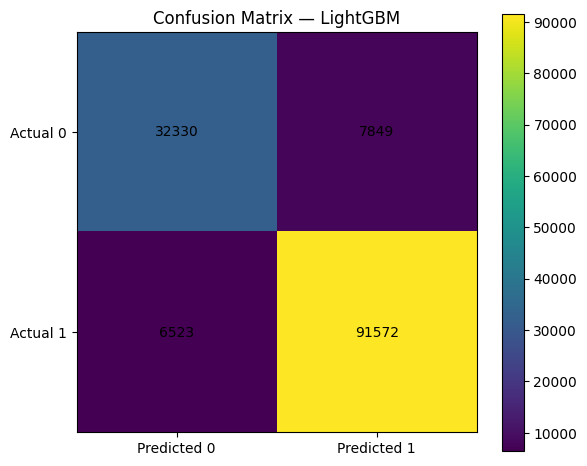

In [22]:
best_model_name = results_df.iloc[0][
    "model_name"
]

best_validation_model = trained_models[
    best_model_name
]

best_class_predictions = (
    best_validation_model.predict(
        X_valid
    )
)

best_probability_predictions = (
    best_validation_model.predict_proba(
        X_valid
    )[:, 1]
)

print("Best validation model:", best_model_name)
print(
    classification_report(
        y_valid,
        best_class_predictions,
    )
)

matrix = confusion_matrix(
    y_valid,
    best_class_predictions,
)

plt.figure(figsize=(6, 5))
plt.imshow(matrix)
plt.colorbar()
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        plt.text(
            column,
            row,
            matrix[row, column],
            ha="center",
            va="center",
        )

plt.title(
    f"Confusion Matrix — {best_model_name}"
)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "best_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 12. Cross-validation of the strongest models

To control runtime, this section evaluates the two strongest validation models with three-fold stratified cross-validation. Increase to five folds for the final report when runtime permits.

In [23]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_map = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "log_loss": "neg_log_loss",
}

sklearn_scoring = scoring_map[
    OFFICIAL_METRIC
]

top_model_names = (
    results_df["model_name"]
    .head(2)
    .tolist()
)

cv_rows = []

for model_name in top_model_names:
    print(
        f"Cross-validating {model_name}..."
    )

    model = clone(models[model_name])

    fold_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring=sklearn_scoring,
        n_jobs=-1,
    )

    if OFFICIAL_METRIC == "log_loss":
        fold_scores = -fold_scores

    cv_rows.append({
        "model_name": model_name,
        "fold_1": fold_scores[0],
        "fold_2": fold_scores[1],
        "fold_3": fold_scores[2],
        "mean_cv_score": fold_scores.mean(),
        "std_cv_score": fold_scores.std(),
    })

cv_results_df = pd.DataFrame(
    cv_rows
).sort_values(
    "mean_cv_score",
    ascending=not higher_is_better,
)

display(cv_results_df)

cv_results_df.to_csv(
    RESULTS_DIR / "cross_validation_results.csv",
    index=False,
)

Cross-validating LightGBM...
Cross-validating Random Forest...


,model_name,fold_1,fold_2,fold_3,mean_cv_score,std_cv_score
0,LightGBM,0.959698,0.960774,0.960673,0.960381,0.000485
1,Random Forest,0.939074,0.940262,0.940061,0.939799,0.000519


## 13. Select and train the final model

The final model is selected from cross-validation rather than from one split alone. It is then retrained on all available labelled training records.

In [24]:
if cv_results_df.empty:
    selected_model_name = best_model_name
else:
    selected_model_name = (
        cv_results_df.iloc[0][
            "model_name"
        ]
    )

final_model = clone(
    models[selected_model_name]
)

print(
    "Selected final model:",
    selected_model_name,
)

final_started_at = time.perf_counter()

final_model.fit(X, y)

final_training_seconds = (
    time.perf_counter()
    - final_started_at
)

print(
    "Final model trained on all rows in",
    round(final_training_seconds, 2),
    "seconds.",
)

Selected final model: LightGBM
Final model trained on all rows in 62.75 seconds.


## 14. Model interpretation

For LightGBM or Random Forest, this section extracts encoded-feature importance. The importance values describe model usage, not causality.

,feature,importance
6,numeric__notifications_per_day,3987
7,numeric__app_opens_per_day,3603
1,numeric__daily_screen_time_hours,1995
8,numeric__weekend_screen_time,1874
2,numeric__social_media_hours,1310
4,numeric__work_study_hours,1232
9,numeric__social_media_ratio,1083
10,numeric__gaming_ratio,813
3,numeric__gaming_hours,607
0,numeric__age,418


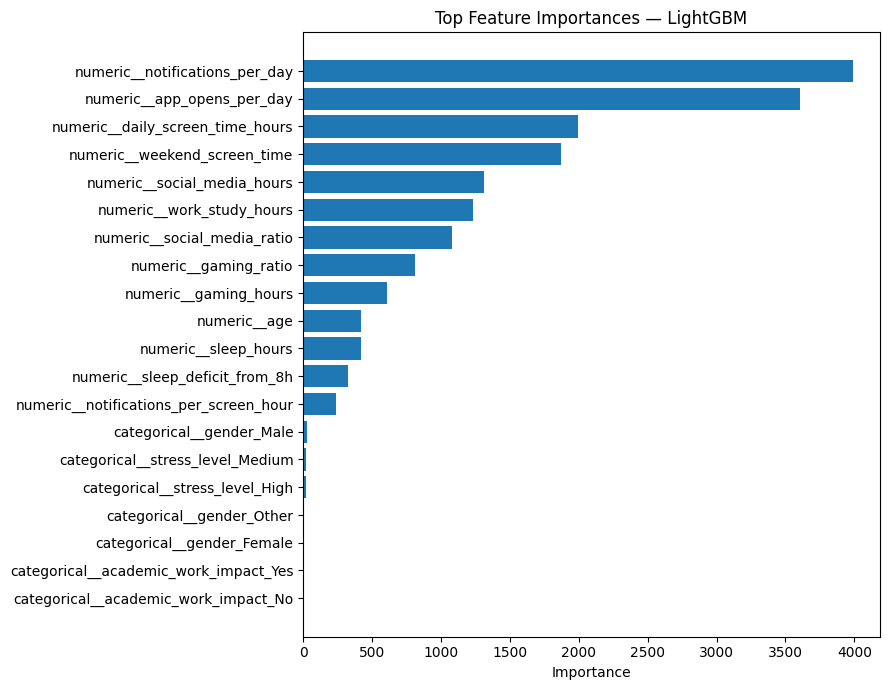

In [25]:
try:
    fitted_preprocessor = final_model.named_steps[
        "preprocessor"
    ]
    fitted_estimator = final_model.named_steps[
        "model"
    ]

    encoded_feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

    if hasattr(
        fitted_estimator,
        "feature_importances_",
    ):
        importances = (
            fitted_estimator
            .feature_importances_
        )

        importance_df = pd.DataFrame({
            "feature": encoded_feature_names,
            "importance": importances,
        }).sort_values(
            "importance",
            ascending=False,
        )

        display(importance_df.head(30))

        importance_df.to_csv(
            RESULTS_DIR / "feature_importance.csv",
            index=False,
        )

        top_importance = (
            importance_df.head(20)
            .sort_values("importance")
        )

        plt.figure(figsize=(9, 7))
        plt.barh(
            top_importance["feature"],
            top_importance["importance"],
        )
        plt.title(
            f"Top Feature Importances — {selected_model_name}"
        )
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.savefig(
            FIGURE_DIR / "feature_importance.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

    elif hasattr(
        fitted_estimator,
        "coef_",
    ):
        coefficients = (
            fitted_estimator.coef_[0]
        )

        coefficient_df = pd.DataFrame({
            "feature": encoded_feature_names,
            "coefficient": coefficients,
            "absolute_coefficient":
                np.abs(coefficients),
        }).sort_values(
            "absolute_coefficient",
            ascending=False,
        )

        display(coefficient_df.head(30))

        coefficient_df.to_csv(
            RESULTS_DIR / "model_coefficients.csv",
            index=False,
        )

    else:
        print(
            "The selected estimator does not expose "
            "direct feature importance."
        )

except Exception as error:
    print(
        "Feature interpretation could not be generated:",
        error,
    )

## 15. Save the model, metadata and environment

The complete pipeline is saved, including preprocessing and the classifier. Loading it in an API should use the same package versions.

In [26]:
model_path = (
    MODEL_DIR
    / "smartphone_addiction_model.joblib"
)

joblib.dump(
    final_model,
    model_path,
)

metadata = {
    "competition":
        "Playground Series Season 6 Episode 8",
    "target_column": TARGET,
    "id_column": ID_COLUMN,
    "feature_columns": feature_columns,
    "numeric_columns": numeric_columns,
    "categorical_columns":
        categorical_columns,
    "engineered_features":
        engineered_features,
    "selected_model":
        selected_model_name,
    "official_metric":
        OFFICIAL_METRIC,
    "random_state":
        RANDOM_STATE,
    "training_rows":
        int(X.shape[0]),
    "training_columns":
        int(X.shape[1]),
    "final_training_seconds":
        final_training_seconds,
}

with open(
    MODEL_DIR / "model_metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

environment = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "joblib": joblib.__version__,
}

with open(
    MODEL_DIR / "environment.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        environment,
        file,
        indent=2,
    )

with open(
    MODEL_DIR / "requirements-model.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        f"pandas=={pd.__version__}\n"
        f"numpy=={np.__version__}\n"
        f"scikit-learn=={sklearn.__version__}\n"
        f"joblib=={joblib.__version__}\n"
        "lightgbm\n"
    )

print("Saved model:", model_path)
print("Saved metadata and environment files.")

Saved model: /content/drive/MyDrive/smartphone-addiction-project/models/smartphone_addiction_model.joblib
Saved metadata and environment files.


## 16. Generate the Kaggle submission

Binary probability predictions are used because the sample submission contains continuous values. Confirm this requirement against Kaggle's Evaluation page before uploading.

In [27]:
if not hasattr(final_model, "predict_proba"):
    raise TypeError(
        "The final model does not support predict_proba."
    )

test_probabilities = (
    final_model.predict_proba(
        X_test
    )[:, 1]
)

submission = sample_submission.copy()

submission_prediction_columns = [
    column
    for column in submission.columns
    if column != ID_COLUMN
]

if len(submission_prediction_columns) != 1:
    raise ValueError(
        "Expected one prediction column in "
        "sample_submission.csv, found: "
        f"{submission_prediction_columns}"
    )

submission_target = (
    submission_prediction_columns[0]
)

submission[submission_target] = (
    test_probabilities
)

submission_path = (
    SUBMISSION_DIR
    / f"submission_{selected_model_name.lower().replace(' ', '_')}.csv"
)

submission.to_csv(
    submission_path,
    index=False,
)

print("Submission saved:", submission_path)
display(submission.head())

Submission saved: /content/drive/MyDrive/smartphone-addiction-project/outputs/submissions/submission_lightgbm.csv


,id,addicted_label
0,691369,0.997828
1,691370,0.955298
2,691371,0.959874
3,691372,0.984705
4,691373,0.994832


In [28]:
# Submission validation

validation_checks = {
    "same_shape_as_sample":
        submission.shape
        == sample_submission.shape,
    "same_columns_as_sample":
        submission.columns.tolist()
        == sample_submission.columns.tolist(),
    "row_count_matches_test":
        len(submission)
        == len(test_df),
    "no_missing_predictions":
        submission[
            submission_target
        ].notna().all(),
    "finite_predictions":
        np.isfinite(
            submission[
                submission_target
            ]
        ).all(),
    "probabilities_in_range":
        submission[
            submission_target
        ].between(0, 1).all(),
}

display(
    pd.DataFrame(
        validation_checks.items(),
        columns=["check", "passed"],
    )
)

if not all(validation_checks.values()):
    raise ValueError(
        "Submission validation failed."
    )

submission_summary = {
    "file": str(submission_path),
    "rows": int(submission.shape[0]),
    "columns": submission.columns.tolist(),
    "prediction_min": float(
        submission[submission_target].min()
    ),
    "prediction_max": float(
        submission[submission_target].max()
    ),
    "prediction_mean": float(
        submission[submission_target].mean()
    ),
    "all_checks_passed": True,
}

with open(
    RESULTS_DIR / "submission_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        submission_summary,
        file,
        indent=2,
    )

print("All submission checks passed.")

,check,passed
0,same_shape_as_sample,True
1,same_columns_as_sample,True
2,row_count_matches_test,True
3,no_missing_predictions,True
4,finite_predictions,True
5,probabilities_in_range,True


All submission checks passed.


## 17. Optional Kaggle API submission

Uncomment and run only after confirming the submission file and competition rules. Manual upload is recommended for the first submission so screenshots can be captured for the report.

In [ ]:
# Optional:
#
# !kaggle competitions submit \
#     -c playground-series-s6e8 \
#     -f "{submission_path}" \
#     -m "Validated baseline and model comparison submission"
#
# !kaggle competitions submissions \
#     -c playground-series-s6e8

## 18. Download important artefacts

The model and submission remain in Google Drive. These commands can also download them to the local computer.

In [29]:
from google.colab import files

print("Model:", model_path)
print("Submission:", submission_path)

# Uncomment one at a time when needed:
# files.download(str(model_path))
# files.download(str(submission_path))

Model: /content/drive/MyDrive/smartphone-addiction-project/models/smartphone_addiction_model.joblib
Submission: /content/drive/MyDrive/smartphone-addiction-project/outputs/submissions/submission_lightgbm.csv


## 19. Experiment log for the report

After every Kaggle submission, update a table similar to the following and include screenshots of the submission history and leaderboard score.

| Version | Model | Local CV score | Public score | Main change |
|---|---|---:|---:|---|
| V1 | Logistic Regression | | | Explainable baseline |
| V2 | Random Forest | | | Bagging ensemble |
| V3 | LightGBM | | | Gradient boosting |
| V4 | Tuned model | | | Hyperparameter optimization |
| V5 | Ensemble | | | Blend of strongest models |

## 20. Critical evaluation prompts

Discuss these points in your report:

- Whether the synthetic competition data represents real smartphone users.
- The effect of target imbalance on accuracy and minority-class performance.
- Privacy and consent for behavioural data.
- Bias across demographic groups.
- The difference between prediction and medical diagnosis.
- False-positive and false-negative consequences.
- Model interpretability and deployment limitations.
- Why deep learning did or did not outperform tree-based models.
- How external validation with real-world data could improve confidence.